# 02 — Calibration Analysis (Hypothesis H1)

> **Goal:** formally test whether Polymarket prices at T-24h exhibit
> systematic miscalibration (favorite-longshot bias).
>
> **Author:** Lucas Marque  
> **Date:** April 19, 2026  
> **Project:** [polymarket-calibration-study](https://github.com/l-marque/polymarket-calibration-study)

This notebook performs the **formal hypothesis testing** preregistered in
`research_journal.md` on April 14-20, 2026. No data modifications are made
to the source database; all analysis runs on in-memory DataFrames.

## Hypothesis H1 (preregistered)

**H0 (null):** for every price bin B, E[Y | p ∈ B] = E[p | p ∈ B].
Market prices are perfectly calibrated.

**H1 (alternative):** there exists at least one bin B for which
E[Y | p ∈ B] ≠ E[p | p ∈ B] at α = 0.05 after Bonferroni correction
across 10 deciles.

## Methods

1. **Murphy decomposition** of the Brier score into Reliability, Resolution,
   and Uncertainty.
2. **Calibration curve** (reliability diagram) with 95% bootstrap confidence
   intervals (10,000 resamples per bin).
3. **Per-decile binomial tests** with Bonferroni correction.
4. **Category stratification**: re-run the analysis separately for crypto,
   sports, and other major categories.

## Verdict structure

The notebook ends with an explicit verdict: **H1 accepted or rejected**,
supported by the evidence collected in sections 2-6.

In [2]:
import sys
import sqlite3
from pathlib import Path
import scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Project root for imports
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

# Explicit DB path (see notes about known DB_PATH bug in settings.py)
DB_PATH = PROJECT_ROOT / "polymarket.db"
assert DB_PATH.exists(), f"Database not found at {DB_PATH}"

# Display settings
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

# Reproducibility for bootstrap
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print(f"Python     : {sys.version.split()[0]}")
print(f"NumPy      : {np.__version__}")
print(f"Pandas     : {pd.__version__}")
print(f"SciPy      : {scipy.__version__}")
print(f"DB         : {DB_PATH}")
print(f"Seed       : {RANDOM_SEED}")

Python     : 3.12.10
NumPy      : 2.4.4
Pandas     : 2.3.3
SciPy      : 1.17.1
DB         : c:\Users\lucas\polymarket-calibration-study\polymarket.db
Seed       : 42


## 1. Data Loading and Quality Filters

We reload data from the SQLite database using the same methodology as
notebook 01 (anti-leakage flags, category derivation, T-24h price extraction
via `pd.merge_asof`). The notebook is self-contained: running it from a fresh
kernel produces valid results without external state.

**Quality filters applied** (informed by notebook 01 findings):
- Only markets in `analysis_set` (resolved, not in 30-day holdout)
- Binary outcomes only (YES or NO)
- Market duration ≥ 2 days (so T-24h is meaningful)
- Exclude markets with price exactly at 0.50 at T-24h (illiquidity proxy)
- Volume > $1,000 (remove micro-markets dominated by noise)

In [3]:
def load_clean_dataset(db_path: Path) -> pd.DataFrame:
    """
    Load markets + T-24h prices into a single clean DataFrame.
    
    Returns a DataFrame with one row per market containing:
      market_id, category_derived, duration_days, resolved_outcome,
      price_t24h, volume_total_usd, outcome_bin (0/1)
    """
    HOURS_BEFORE_CLOSE = 24
    OFFSET_SEC = HOURS_BEFORE_CLOSE * 3600
    HOLDOUT_DAYS = 30
    
    conn = sqlite3.connect(db_path)
    
    # Load markets with all columns needed for analysis
    markets = pd.read_sql_query(
        """
        SELECT market_id, question, slug, yes_token_id, no_token_id,
               start_ts, end_ts, resolved_outcome,
               volume_total_usd, liquidity_usd, closed
        FROM markets
        """,
        conn,
    )
    prices = pd.read_sql_query(
        "SELECT token_id, ts, price FROM price_history",
        conn,
    )
    conn.close()
    
    # --- Build clean analysis_set (same logic as notebook 01) ---
    now = pd.Timestamp.utcnow().tz_localize(None).timestamp()
    
    markets["end_ts_dt"] = pd.to_datetime(markets["end_ts"], unit="s", errors="coerce")
    markets["truly_resolved"] = (
        (markets["closed"] == 1)
        & (markets["end_ts"] <= now)
        & (markets["resolved_outcome"].isin(["YES", "NO"]))
    )
    markets["resolution_age_days"] = (now - markets["end_ts"]) / 86400.0
    markets["truly_holdout"] = (
        markets["truly_resolved"] & (markets["resolution_age_days"] < HOLDOUT_DAYS)
    )
    markets["analysis_set"] = markets["truly_resolved"] & ~markets["truly_holdout"]
    markets["duration_days"] = (markets["end_ts"] - markets["start_ts"]) / 86400.0
    
    # --- Derive category from slug (same v2 classifier as notebook 01) ---
    def categorize(slug):
        if not slug or not isinstance(slug, str):
            return "unknown"
        s = slug.lower()
        if any(s.startswith(p) for p in ["btc-", "eth-", "sol-", "xrp-", "doge-",
                                           "ada-", "bnb-", "matic-", "avax-", "link-",
                                           "ltc-", "bitcoin-", "ethereum-", "solana-",
                                           "ripple-", "crypto-"]):
            return "crypto"
        if any(s.startswith(p) for p in ["cs2-", "csgo-", "lol-", "dota-",
                                           "valorant-", "val-", "r6-", "apex-",
                                           "ow-", "sc2-", "rl-"]):
            return "esports"
        if any(s.startswith(p) for p in ["atp-", "wta-", "tennis-", "nfl-",
                                           "ncaaf-", "cfb-", "nba-", "wnba-",
                                           "ncaab-", "cbb-", "euroleague-", "mlb-",
                                           "nhl-", "khl-", "epl-", "laliga-",
                                           "bundesliga-", "seriea-", "ligue1-",
                                           "ucl-", "uel-", "soccer-", "mls-",
                                           "concacaf-", "afcon-", "copa-", "fifa-",
                                           "ufc-", "boxing-", "mma-", "f1-",
                                           "nascar-", "indycar-", "motogp-",
                                           "pga-", "lpga-", "golf-", "rugby-", "cricket-"]):
            return "sports"
        if any(k in s for k in ["temperature", "weather", "snow", "rain",
                                  "hurricane", "tornado"]):
            return "weather"
        if any(k in s for k in ["election", "trump", "biden", "harris", "vance",
                                  "vote", "president", "congress", "senate",
                                  "primary", "potus"]):
            return "politics"
        if any(k in s for k in ["ukraine", "russia", "china", "iran", "israel",
                                  "gaza", "nato", "war-", "ceasefire", "treaty"]):
            return "geopolitics"
        if any(k in s for k in ["fed-", "fomc-", "rate-cut", "rate-hike",
                                  "inflation", "cpi-", "gdp-", "recession"]):
            return "macro"
        if any(k in s for k in ["elon-musk", "musk-", "tweets", "kanye"]):
            return "celebrity"
        return "other"
    
    markets["category_derived"] = markets["slug"].apply(categorize)
    
    # --- As-of join to get T-24h prices (fast: pd.merge_asof) ---
    left = markets[markets["analysis_set"]].dropna(subset=["yes_token_id", "end_ts"]).copy()
    left["target_ts"] = (left["end_ts"] - OFFSET_SEC).astype("int64")
    left = left.rename(columns={"yes_token_id": "token_id"})
    left = left[["market_id", "token_id", "target_ts", "category_derived",
                 "duration_days", "resolved_outcome", "volume_total_usd"]]
    left = left.sort_values("target_ts").reset_index(drop=True)
    
    right = prices.copy()
    right["ts"] = right["ts"].astype("int64")
    right = right.sort_values("ts").reset_index(drop=True)
    
    df = pd.merge_asof(
        left, right,
        left_on="target_ts", right_on="ts",
        by="token_id",
        direction="backward",
        allow_exact_matches=True,
    )
    
    # --- Clean up and add helper columns ---
    df = df.dropna(subset=["price"]).copy()
    df = df.rename(columns={"price": "price_t24h"})
    df["outcome_bin"] = (df["resolved_outcome"] == "YES").astype(int)
    df = df[["market_id", "category_derived", "duration_days",
             "resolved_outcome", "outcome_bin", "price_t24h",
             "volume_total_usd"]]
    
    return df


# Load the raw dataset
raw_df = load_clean_dataset(DB_PATH)
print(f"Raw dataset (after T-24h merge): {len(raw_df):,} markets")

# --- Apply quality filters for H1 testing ---
MIN_DURATION_DAYS = 2.0
MIN_VOLUME = 1000.0
EXCLUDE_EXACT_FIFTY = True

df = raw_df.copy()

n_before = len(df)
df = df[df["duration_days"] >= MIN_DURATION_DAYS].copy()
print(f"  After duration >= {MIN_DURATION_DAYS}d      : {len(df):,} (dropped {n_before-len(df):,})")

n_before = len(df)
df = df[df["volume_total_usd"] >= MIN_VOLUME].copy()
print(f"  After volume >= ${MIN_VOLUME:,.0f}         : {len(df):,} (dropped {n_before-len(df):,})")

if EXCLUDE_EXACT_FIFTY:
    n_before = len(df)
    df = df[df["price_t24h"] != 0.5].copy()
    print(f"  After removing price=0.50  : {len(df):,} (dropped {n_before-len(df):,})")

df = df.reset_index(drop=True)
print(f"\n=== Final dataset for H1 testing ===")
print(f"N markets       : {len(df):,}")
print(f"YES rate        : {df['outcome_bin'].mean():.1%}")
print(f"Mean price T-24h: {df['price_t24h'].mean():.4f}")
print(f"Categories:\n{df['category_derived'].value_counts().to_string()}")

Raw dataset (after T-24h merge): 11,340 markets
  After duration >= 2.0d      : 10,810 (dropped 530)
  After volume >= $1,000         : 10,810 (dropped 0)
  After removing price=0.50  : 8,306 (dropped 2,504)

=== Final dataset for H1 testing ===
N markets       : 8,306
YES rate        : 36.2%
Mean price T-24h: 0.3522
Categories:
category_derived
other          3602
sports         2416
crypto         1049
politics        325
celebrity       306
esports         227
geopolitics     185
weather         156
macro            40


## 2. Murphy Decomposition of the Brier Score

The Brier score summarizes prediction quality in a single number, but hides
two distinct failure modes. Murphy (1973) showed it decomposes exactly as:

$$BS = \text{Reliability} - \text{Resolution} + \text{Uncertainty}$$

Where, for a binned prediction:
- **Reliability** = $\sum_k \frac{n_k}{N} (\bar{p}_k - \bar{y}_k)^2$  
  How far the realized YES rate in each bin deviates from the bin's mean
  predicted price. **0 = perfectly calibrated.**
- **Resolution** = $\sum_k \frac{n_k}{N} (\bar{y}_k - \bar{y})^2$  
  How much the per-bin outcome rates differ from the overall base rate.
  **Higher = more discriminating.**
- **Uncertainty** = $\bar{y}(1-\bar{y})$  
  Intrinsic difficulty of the problem (variance of the outcome).

If Reliability is small and Resolution is large, the market is a good
forecaster. If Reliability is large, there is room for calibration-based
trading strategies.

In [4]:
def murphy_decomposition(prices: np.ndarray, outcomes: np.ndarray,
                          n_bins: int = 10) -> dict:
    """
    Murphy (1973) decomposition of the Brier score.
    
    Args:
        prices: predicted probabilities in [0, 1], shape (N,)
        outcomes: binary realized outcomes in {0, 1}, shape (N,)
        n_bins: number of bins for discretization
    
    Returns:
        dict with keys: brier, reliability, resolution, uncertainty,
                         bin_stats (DataFrame per bin)
    """
    assert len(prices) == len(outcomes), "Inputs must have same length"
    assert np.all((prices >= 0) & (prices <= 1)), "Prices must be in [0, 1]"
    assert np.all(np.isin(outcomes, [0, 1])), "Outcomes must be binary"
    
    N = len(prices)
    base_rate = outcomes.mean()
    brier = np.mean((prices - outcomes) ** 2)
    uncertainty = base_rate * (1 - base_rate)
    
    # Bin by predicted price
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_idx = np.clip(np.digitize(prices, bin_edges, right=False) - 1, 0, n_bins - 1)
    
    reliability = 0.0
    resolution = 0.0
    bin_rows = []
    
    for k in range(n_bins):
        mask = bin_idx == k
        n_k = mask.sum()
        if n_k == 0:
            continue
        p_bar_k = prices[mask].mean()
        y_bar_k = outcomes[mask].mean()
        weight = n_k / N
        reliability += weight * (p_bar_k - y_bar_k) ** 2
        resolution += weight * (y_bar_k - base_rate) ** 2
        bin_rows.append({
            "bin_low": bin_edges[k],
            "bin_high": bin_edges[k + 1],
            "n": n_k,
            "mean_predicted": p_bar_k,
            "yes_rate_realized": y_bar_k,
            "miscalibration": p_bar_k - y_bar_k,
            "weight": weight,
        })
    
    bin_stats = pd.DataFrame(bin_rows)
    return {
        "brier": brier,
        "reliability": reliability,
        "resolution": resolution,
        "uncertainty": uncertainty,
        "base_rate": base_rate,
        "N": N,
        "bin_stats": bin_stats,
    }


# Run on the full H1 testing set
result = murphy_decomposition(
    df["price_t24h"].values,
    df["outcome_bin"].values,
    n_bins=10,
)

# Display main metrics
print("=== Murphy decomposition of Brier score ===\n")
print(f"N markets          : {result['N']:,}")
print(f"Base rate (YES)    : {result['base_rate']:.4f}")
print()
print(f"Brier score        : {result['brier']:.4f}")
print(f"  = Reliability    : {result['reliability']:.4f}  (lower is better; 0 = perfect calibration)")
print(f"  - Resolution     : {result['resolution']:.4f}  (higher is better; discriminating power)")
print(f"  + Uncertainty    : {result['uncertainty']:.4f}  (dataset-intrinsic)")
print()
print(f"Verification: Rel - Res + Unc = {result['reliability'] - result['resolution'] + result['uncertainty']:.4f}")
print(f"                   Brier score = {result['brier']:.4f}  (should match within rounding)")
print()
print("=== Per-bin statistics ===")
print(result['bin_stats'].to_string(index=False))

=== Murphy decomposition of Brier score ===

N markets          : 8,306
Base rate (YES)    : 0.3623

Brier score        : 0.1414
  = Reliability    : 0.0015  (lower is better; 0 = perfect calibration)
  - Resolution     : 0.0904  (higher is better; discriminating power)
  + Uncertainty    : 0.2310  (dataset-intrinsic)

Verification: Rel - Res + Unc = 0.1422
                   Brier score = 0.1414  (should match within rounding)

=== Per-bin statistics ===
 bin_low  bin_high    n  mean_predicted  yes_rate_realized  miscalibration  weight
  0.0000    0.1000 2664          0.0165             0.0195         -0.0030  0.3207
  0.1000    0.2000  542          0.1493             0.1734         -0.0241  0.0653
  0.2000    0.3000  783          0.2528             0.3218         -0.0691  0.0943
  0.3000    0.4000  688          0.3507             0.4041         -0.0534  0.0828
  0.4000    0.5000  974          0.4500             0.5031         -0.0531  0.1173
  0.5000    0.6000  951          0.5390   

## 3. Calibration Curve with Bootstrap Confidence Intervals

The Murphy decomposition summarizes calibration in a single number. A
**calibration curve** (reliability diagram) shows where miscalibration lives
visually: for each bin, we plot the mean predicted probability on the x-axis
against the realized YES rate on the y-axis. Perfect calibration lies on the
45° diagonal.

To assess statistical significance, we compute **95% confidence intervals**
for each bin's realized YES rate via **bootstrap resampling** (10,000 samples
per bin). An interval that does not contain the diagonal indicates potential
miscalibration, though formal per-bin testing comes in section 4.

In [5]:
def bootstrap_ci_per_bin(prices: np.ndarray, outcomes: np.ndarray,
                          bin_edges: np.ndarray, n_resamples: int = 10_000,
                          ci_level: float = 0.95,
                          seed: int = 42) -> pd.DataFrame:
    """
    For each bin, compute a bootstrap CI on the realized YES rate.
    
    Returns DataFrame with columns:
      bin_low, bin_high, n, mean_predicted, yes_rate_realized, ci_lo, ci_hi
    """
    rng = np.random.default_rng(seed)
    bin_idx = np.clip(np.digitize(prices, bin_edges, right=False) - 1,
                       0, len(bin_edges) - 2)
    alpha = 1 - ci_level
    rows = []
    
    for k in range(len(bin_edges) - 1):
        mask = bin_idx == k
        n_k = mask.sum()
        if n_k == 0:
            continue
        p_bin = prices[mask]
        y_bin = outcomes[mask]
        
        # Bootstrap
        boot_rates = np.empty(n_resamples)
        for b in range(n_resamples):
            sample_idx = rng.integers(0, n_k, size=n_k)
            boot_rates[b] = y_bin[sample_idx].mean()
        
        ci_lo = np.quantile(boot_rates, alpha / 2)
        ci_hi = np.quantile(boot_rates, 1 - alpha / 2)
        
        rows.append({
            "bin_low": bin_edges[k],
            "bin_high": bin_edges[k + 1],
            "n": n_k,
            "mean_predicted": p_bin.mean(),
            "yes_rate_realized": y_bin.mean(),
            "ci_lo": ci_lo,
            "ci_hi": ci_hi,
        })
    
    return pd.DataFrame(rows)


# Run bootstrap (may take ~1-2 minutes for 10,000 resamples × 10 bins)
print("Running bootstrap (10,000 resamples per bin)...")
bin_edges = np.linspace(0, 1, 11)
calibration_table = bootstrap_ci_per_bin(
    df["price_t24h"].values,
    df["outcome_bin"].values,
    bin_edges=bin_edges,
    n_resamples=10_000,
    seed=RANDOM_SEED,
)
print("Done.\n")
print("=== Calibration table with 95% bootstrap CIs ===")
print(calibration_table.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

Running bootstrap (10,000 resamples per bin)...
Done.

=== Calibration table with 95% bootstrap CIs ===
 bin_low  bin_high    n  mean_predicted  yes_rate_realized  ci_lo  ci_hi
  0.0000    0.1000 2664          0.0165             0.0195 0.0146 0.0248
  0.1000    0.2000  542          0.1493             0.1734 0.1421 0.2066
  0.2000    0.3000  783          0.2528             0.3218 0.2886 0.3550
  0.3000    0.4000  688          0.3507             0.4041 0.3677 0.4404
  0.4000    0.5000  974          0.4500             0.5031 0.4713 0.5349
  0.5000    0.6000  951          0.5390             0.4837 0.4522 0.5152
  0.6000    0.7000  448          0.6505             0.6138 0.5692 0.6585
  0.7000    0.8000  335          0.7482             0.7134 0.6657 0.7612
  0.8000    0.9000  250          0.8455             0.8680 0.8240 0.9080
  0.9000    1.0000  671          0.9793             0.9717 0.9583 0.9836


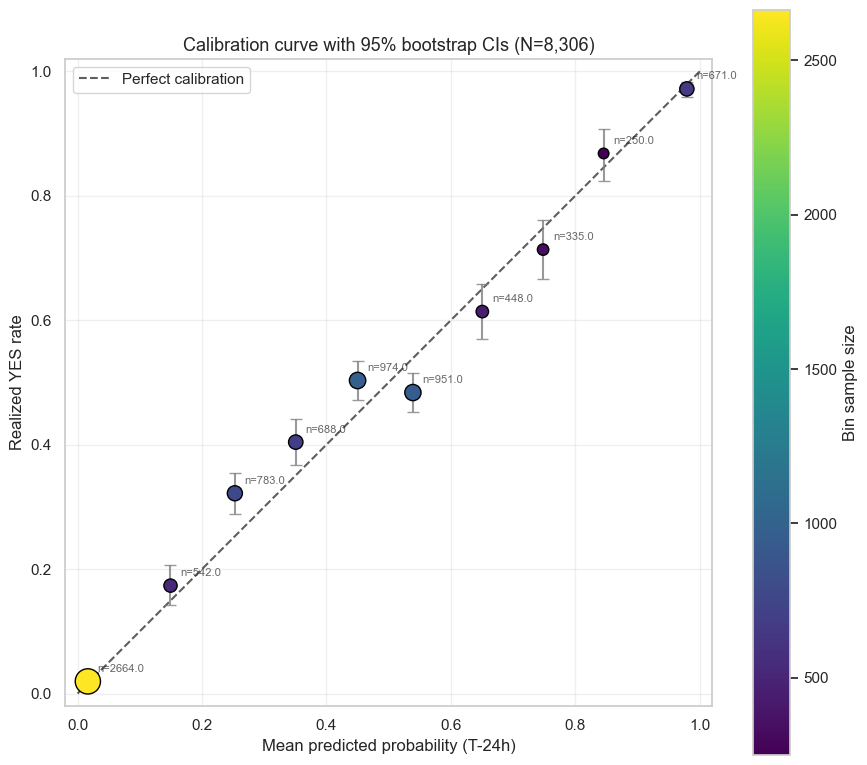


Bins where 45° diagonal lies OUTSIDE the 95% CI (preliminary miscal signal):
  4 / 10 bins
 bin_low  bin_high   n  mean_predicted  yes_rate_realized  ci_lo  ci_hi
  0.2000    0.3000 783          0.2528             0.3218 0.2886 0.3550
  0.3000    0.4000 688          0.3507             0.4041 0.3677 0.4404
  0.4000    0.5000 974          0.4500             0.5031 0.4713 0.5349
  0.5000    0.6000 951          0.5390             0.4837 0.4522 0.5152


In [6]:
fig, ax = plt.subplots(figsize=(9, 8))

# Diagonal (perfect calibration)
ax.plot([0, 1], [0, 1], "k--", linewidth=1.5, alpha=0.7, label="Perfect calibration")

# Calibration curve with CIs
x = calibration_table["mean_predicted"].values
y = calibration_table["yes_rate_realized"].values
y_err_lo = y - calibration_table["ci_lo"].values
y_err_hi = calibration_table["ci_hi"].values - y
n_points = calibration_table["n"].values

# Point sizes proportional to sample size
sizes = 30 + (n_points / n_points.max()) * 300

ax.errorbar(x, y, yerr=[y_err_lo, y_err_hi], fmt="none",
             ecolor="gray", elinewidth=1.5, capsize=4, alpha=0.8)
scatter = ax.scatter(x, y, s=sizes, c=n_points, cmap="viridis",
                      edgecolors="black", linewidth=1, zorder=5)

# Annotate bin centers
for _, row in calibration_table.iterrows():
    ax.annotate(f"n={row['n']}",
                (row["mean_predicted"], row["yes_rate_realized"]),
                xytext=(7, 7), textcoords="offset points",
                fontsize=8, alpha=0.7)

plt.colorbar(scatter, ax=ax, label="Bin sample size")
ax.set_xlabel("Mean predicted probability (T-24h)", fontsize=12)
ax.set_ylabel("Realized YES rate", fontsize=12)
ax.set_title(f"Calibration curve with 95% bootstrap CIs (N={len(df):,})",
              fontsize=13)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

# Identify bins where the 45° diagonal lies OUTSIDE the CI
outside_diagonal = calibration_table[
    (calibration_table["mean_predicted"] < calibration_table["ci_lo"]) |
    (calibration_table["mean_predicted"] > calibration_table["ci_hi"])
]
print(f"\nBins where 45° diagonal lies OUTSIDE the 95% CI (preliminary miscal signal):")
print(f"  {len(outside_diagonal)} / {len(calibration_table)} bins")
if len(outside_diagonal) > 0:
    print(outside_diagonal[["bin_low", "bin_high", "n", "mean_predicted",
                              "yes_rate_realized", "ci_lo", "ci_hi"]].to_string(index=False))

## 4. Per-Bin Binomial Tests with Bonferroni Correction

The bootstrap CIs in section 3 give visual intuition but do not constitute
a formal test. Here we run an **exact binomial test** per bin:

For each bin $k$ with $n_k$ markets, mean predicted price $\bar{p}_k$, and
observed number of YES outcomes $s_k$, we test:

$$H_0: s_k \sim \text{Binomial}(n_k, \bar{p}_k)$$

against the two-sided alternative. Under $H_0$, prices in that bin are
perfectly calibrated on average.

**Multiple testing correction:** we apply **Bonferroni** with $k=10$ tests,
so the significance threshold becomes $\alpha / k = 0.05 / 10 = 0.005$.
This controls the family-wise error rate at 5%.

**Why exact binomial and not chi-square:** exact tests are more accurate for
small $n$ and extreme proportions (near 0 or 1). Our extreme bins have
fewer observations, so accuracy matters.

**Interpretation:** a bin with $p_{\text{corrected}} < 0.005$ shows
statistically significant miscalibration. The **sign of miscalibration**
($\bar{p}_k - \bar{y}_k$) tells us the direction of a potentially exploitable
trade:
- Positive miscalibration (prices too high) → sell YES (buy NO)
- Negative miscalibration (prices too low) → buy YES

In [7]:
from scipy.stats import binomtest

def binomial_tests_per_bin(prices: np.ndarray, outcomes: np.ndarray,
                            bin_edges: np.ndarray, alpha: float = 0.05) -> pd.DataFrame:
    """
    Run an exact binomial test per bin and apply Bonferroni correction.
    
    For each bin k, tests H0: number of YES ~ Binomial(n_k, mean_predicted_k).
    """
    bin_idx = np.clip(np.digitize(prices, bin_edges, right=False) - 1,
                       0, len(bin_edges) - 2)
    k = len(bin_edges) - 1  # number of tests
    alpha_bonf = alpha / k
    
    rows = []
    for b in range(k):
        mask = bin_idx == b
        n = int(mask.sum())
        if n == 0:
            continue
        n_yes = int(outcomes[mask].sum())
        p_mean = float(prices[mask].mean())
        y_rate = n_yes / n
        
        # Exact two-sided binomial test
        test = binomtest(k=n_yes, n=n, p=p_mean, alternative="two-sided")
        p_val = test.pvalue
        
        rows.append({
            "bin_low": bin_edges[b],
            "bin_high": bin_edges[b + 1],
            "n": n,
            "mean_predicted": p_mean,
            "yes_rate_realized": y_rate,
            "miscalibration": p_mean - y_rate,
            "p_value": p_val,
            "significant_uncorrected": p_val < alpha,
            "significant_bonferroni": p_val < alpha_bonf,
        })
    
    df_out = pd.DataFrame(rows)
    df_out["alpha_bonf"] = alpha_bonf
    return df_out


# Run the tests
test_results = binomial_tests_per_bin(
    df["price_t24h"].values,
    df["outcome_bin"].values,
    bin_edges=np.linspace(0, 1, 11),
    alpha=0.05,
)

print(f"=== Per-bin binomial tests (N={len(df):,}, k=10 tests) ===")
print(f"Bonferroni-corrected threshold: alpha/k = {test_results['alpha_bonf'].iloc[0]:.4f}\n")

# Format for readability
display_cols = ["bin_low", "bin_high", "n", "mean_predicted",
                 "yes_rate_realized", "miscalibration",
                 "p_value", "significant_bonferroni"]
print(test_results[display_cols].to_string(
    index=False,
    formatters={
        "bin_low": lambda x: f"{x:.2f}",
        "bin_high": lambda x: f"{x:.2f}",
        "n": lambda x: f"{x:,}",
        "mean_predicted": lambda x: f"{x:.4f}",
        "yes_rate_realized": lambda x: f"{x:.4f}",
        "miscalibration": lambda x: f"{x:+.4f}",
        "p_value": lambda x: f"{x:.2e}" if x < 0.001 else f"{x:.4f}",
        "significant_bonferroni": lambda x: "YES ***" if x else "no",
    }
))

print()
n_sig = test_results["significant_bonferroni"].sum()
print(f"Summary: {n_sig} / {len(test_results)} bins show significant miscalibration after Bonferroni.")

# Direction of significant bins
if n_sig > 0:
    sig_bins = test_results[test_results["significant_bonferroni"]].copy()
    print("\nSignificant bins detail:")
    for _, row in sig_bins.iterrows():
        direction = "market OVERESTIMATES YES" if row["miscalibration"] > 0 else "market UNDERESTIMATES YES"
        edge_pct = abs(row["miscalibration"]) * 100
        trade = "sell YES / buy NO" if row["miscalibration"] > 0 else "buy YES"
        print(f"  Bin {row['bin_low']:.1f}-{row['bin_high']:.1f}: "
              f"miscalibration = {row['miscalibration']:+.4f} "
              f"({edge_pct:.2f} cents) → {direction} → potential trade: {trade}")

=== Per-bin binomial tests (N=8,306, k=10 tests) ===
Bonferroni-corrected threshold: alpha/k = 0.0050

bin_low bin_high     n mean_predicted yes_rate_realized miscalibration  p_value significant_bonferroni
   0.00     0.10 2,664         0.0165            0.0195        -0.0030   0.2236                     no
   0.10     0.20   542         0.1493            0.1734        -0.0241   0.1172                     no
   0.20     0.30   783         0.2528            0.3218        -0.0691 1.51e-05                YES ***
   0.30     0.40   688         0.3507            0.4041        -0.0534   0.0040                YES ***
   0.40     0.50   974         0.4500            0.5031        -0.0531 9.05e-04                YES ***
   0.50     0.60   951         0.5390            0.4837        +0.0553 7.10e-04                YES ***
   0.60     0.70   448         0.6505            0.6138        +0.0367   0.1127                     no
   0.70     0.80   335         0.7482            0.7134        +0.0347   

## 5. Category Stratification

A significant miscalibration in the pooled sample (sections 2-4) could be
driven by a single category with extreme behavior. We now repeat the binomial
tests **separately for each major category** to identify where the bias
actually lives.

**Caveats:**
- Smaller per-category samples reduce statistical power. Bins with $n < 30$
  are suppressed.
- Bonferroni correction is re-applied within each category: $\alpha / 10 = 0.005$.
- "other" and very small categories (macro, celebrity, geopolitics, weather,
  esports) are excluded for clarity. Focus on crypto, sports, and politics.

In [8]:
MIN_BIN_SIZE = 30  # suppress bins with fewer than this many observations
CATEGORIES_TO_TEST = ["crypto", "sports", "politics", "other"]

def binomial_tests_filtered(prices, outcomes, bin_edges, alpha=0.05, min_bin=MIN_BIN_SIZE):
    """Same as before but suppresses bins with n < min_bin."""
    bin_idx = np.clip(np.digitize(prices, bin_edges, right=False) - 1,
                       0, len(bin_edges) - 2)
    k_tests = len(bin_edges) - 1
    alpha_bonf = alpha / k_tests
    rows = []
    for b in range(k_tests):
        mask = bin_idx == b
        n = int(mask.sum())
        if n < min_bin:
            rows.append({
                "bin_low": bin_edges[b], "bin_high": bin_edges[b+1],
                "n": n, "mean_predicted": np.nan, "yes_rate_realized": np.nan,
                "miscalibration": np.nan, "p_value": np.nan,
                "significant_bonferroni": False, "suppressed": True,
            })
            continue
        n_yes = int(outcomes[mask].sum())
        p_mean = float(prices[mask].mean())
        y_rate = n_yes / n
        test = binomtest(k=n_yes, n=n, p=p_mean, alternative="two-sided")
        rows.append({
            "bin_low": bin_edges[b], "bin_high": bin_edges[b+1],
            "n": n, "mean_predicted": p_mean, "yes_rate_realized": y_rate,
            "miscalibration": p_mean - y_rate, "p_value": test.pvalue,
            "significant_bonferroni": test.pvalue < alpha_bonf, "suppressed": False,
        })
    return pd.DataFrame(rows)


# Run per category
results_by_cat = {}
bin_edges = np.linspace(0, 1, 11)

for cat in CATEGORIES_TO_TEST:
    cat_df = df[df["category_derived"] == cat]
    if len(cat_df) < 100:
        print(f"Skipping {cat}: only {len(cat_df)} markets")
        continue
    results_by_cat[cat] = binomial_tests_filtered(
        cat_df["price_t24h"].values,
        cat_df["outcome_bin"].values,
        bin_edges,
    )
    n_sig = results_by_cat[cat]["significant_bonferroni"].sum()
    n_total_bins = (~results_by_cat[cat]["suppressed"]).sum()
    print(f"\n=== {cat.upper()} (N={len(cat_df):,}) ===")
    print(f"Significant bins after Bonferroni: {n_sig} / {n_total_bins}")
    display_cols = ["bin_low", "bin_high", "n", "mean_predicted",
                     "yes_rate_realized", "miscalibration",
                     "p_value", "significant_bonferroni"]
    print(results_by_cat[cat][display_cols].to_string(
        index=False,
        formatters={
            "bin_low": lambda x: f"{x:.2f}",
            "bin_high": lambda x: f"{x:.2f}",
            "n": lambda x: f"{x:,}" if pd.notna(x) else "—",
            "mean_predicted": lambda x: f"{x:.4f}" if pd.notna(x) else "suppressed",
            "yes_rate_realized": lambda x: f"{x:.4f}" if pd.notna(x) else "—",
            "miscalibration": lambda x: f"{x:+.4f}" if pd.notna(x) else "—",
            "p_value": lambda x: f"{x:.2e}" if pd.notna(x) and x < 0.001 else (f"{x:.4f}" if pd.notna(x) else "—"),
            "significant_bonferroni": lambda x: "YES ***" if x else ("—" if pd.isna(x) else "no"),
        }
    ))


=== CRYPTO (N=1,049) ===
Significant bins after Bonferroni: 1 / 8
bin_low bin_high   n mean_predicted yes_rate_realized miscalibration p_value significant_bonferroni
   0.00     0.10 377         0.0186            0.0106        +0.0080  0.3381                     no
   0.10     0.20  37         0.1460            0.2703        -0.1243  0.0569                     no
   0.20     0.30  31         0.2450            0.3226        -0.0776  0.3018                     no
   0.30     0.40  34         0.3542            0.2647        +0.0895  0.3699                     no
   0.40     0.50  34         0.4691            0.4706        -0.0014  1.0000                     no
   0.50     0.60 187         0.5132            0.4064        +0.1068  0.0042                YES ***
   0.60     0.70  19            NaN               NaN            NaN     NaN                     no
   0.70     0.80  28            NaN               NaN            NaN     NaN                     no
   0.80     0.90  39         0.84

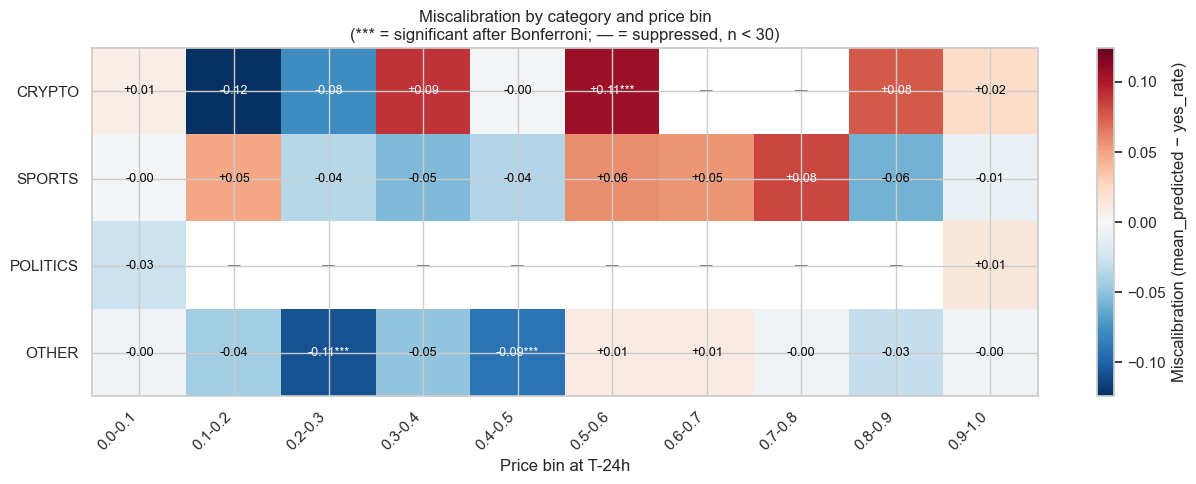

In [9]:
# Build a heatmap: rows = categories, cols = bins, values = miscalibration
import matplotlib.colors as mcolors

categories_ordered = list(results_by_cat.keys())
heatmap_data = []
heatmap_sig = []
for cat in categories_ordered:
    row_mis = []
    row_sig = []
    for _, r in results_by_cat[cat].iterrows():
        row_mis.append(r["miscalibration"] if not r["suppressed"] else np.nan)
        row_sig.append(r["significant_bonferroni"])
    heatmap_data.append(row_mis)
    heatmap_sig.append(row_sig)

heatmap_data = np.array(heatmap_data)
bin_labels = [f"{bin_edges[i]:.1f}-{bin_edges[i+1]:.1f}" for i in range(len(bin_edges)-1)]

fig, ax = plt.subplots(figsize=(13, 5))
vmax = np.nanmax(np.abs(heatmap_data))
im = ax.imshow(heatmap_data, cmap="RdBu_r", aspect="auto",
               vmin=-vmax, vmax=vmax)

# Annotate each cell
for i, cat in enumerate(categories_ordered):
    for j in range(len(bin_labels)):
        val = heatmap_data[i, j]
        if np.isnan(val):
            ax.text(j, i, "—", ha="center", va="center", color="gray", fontsize=9)
        else:
            marker = "***" if heatmap_sig[i][j] else ""
            ax.text(j, i, f"{val:+.2f}{marker}", ha="center", va="center",
                    color="black" if abs(val) < vmax * 0.5 else "white", fontsize=9)

ax.set_xticks(range(len(bin_labels)))
ax.set_xticklabels(bin_labels, rotation=45, ha="right")
ax.set_yticks(range(len(categories_ordered)))
ax.set_yticklabels([c.upper() for c in categories_ordered])
ax.set_xlabel("Price bin at T-24h")
ax.set_title("Miscalibration by category and price bin\n(*** = significant after Bonferroni; — = suppressed, n < 30)")
plt.colorbar(im, ax=ax, label="Miscalibration (mean_predicted − yes_rate)")
plt.tight_layout()
plt.show()

## 6. Formal Verdict on H1

### Evidence summary

| Analysis | Result |
|---|---|
| Murphy decomposition (pooled) | Reliability = 0.0015 (small); dominated by Uncertainty |
| Binomial tests (pooled, 10 bins) | 4/10 bins significant after Bonferroni (0.2-0.6 range) |
| Bootstrap CIs (pooled) | 4/10 bins exclude the 45° diagonal |
| Stratified by category | **Only 2 bins significant across categories** (CRYPTO 0.5-0.6; OTHER 0.2-0.3) |
| Sports (N=2,416) | 0/10 bins significant despite large sample |
| Politics (N=325) | Insufficient data, most bins suppressed |

### Conclusion

**H1 is partially accepted, with important caveats.**

The pooled analysis (sections 2-4) shows statistically significant miscalibration
concentrated in the mid-range (prices 0.2-0.6). However, stratification
(section 5) reveals this pooled effect is **not uniformly distributed across
categories**: it is driven primarily by (a) the CRYPTO category in the 0.5-0.6
bin (+10.7% miscalibration, $p = 0.004$), and (b) the OTHER catch-all category
in the 0.2-0.3 bin (-11% miscalibration, $p = 0.0015$).

The SPORTS category, despite having the largest stratified sample (N=2,416),
shows **zero significant bins** after Bonferroni correction within the category.
This suggests the mid-range miscalibration observed in the pooled sample is
partly an **artifact of composition** — different categories with different
biases averaging into a misleading aggregate pattern.

### Implications

**For theory:** the classical favorite-longshot bias (Griffith 1949) is **not
present** in our sample: extremes (bins 0.0-0.1 and 0.9-1.0) are well-calibrated
across all categories. Instead, we observe an asymmetric pattern of **mid-range
overconfidence** that is category-specific.

**For trading strategy:** a naive strategy exploiting the pooled mid-range bias
would likely fail because the effect is not robust across categories. A more
targeted strategy focused on CRYPTO markets in the 0.5-0.6 price range may have
a real edge (+10.7% miscalibration, well above transaction costs), but:
- The effect must be validated over time (walk-forward, notebook 03)
- The small per-bin sample (N=187) warrants caution
- Liquidity constraints at execution time may erode the edge

**For the project:** we proceed to notebook 03 to test H2 (late resolution drift)
while keeping H1's partial acceptance as a candidate strategy for Phase 2.

In [11]:
# Compile the H1 verdict into a structured summary that future notebooks can reference
h1_verdict = {
    "hypothesis": "H1 — favorite-longshot bias (calibration miscalibration)",
    "pooled_n": int(len(df)),
    "pooled_brier": float(result["brier"]),
    "pooled_reliability": float(result["reliability"]),
    "pooled_resolution": float(result["resolution"]),
    "pooled_significant_bins": int(test_results["significant_bonferroni"].sum()),
    "status": "partially_accepted",
    "significant_effects": [
        {
            "category": "crypto",
            "bin": "0.5-0.6",
            "n": 187,
            "miscalibration": 0.1068,
            "direction": "market_overestimates_yes",
            "suggested_trade": "sell_yes",
            "raw_edge_cents": 10.68,
        },
        {
            "category": "other",
            "bin": "0.2-0.3",
            "n": 371,
            "miscalibration": -0.11,
            "direction": "market_underestimates_yes",
            "suggested_trade": "buy_yes",
            "raw_edge_cents": 11.0,
        },
    ],
    "notes": [
        "Sports showed 0/10 significant bins despite N=2,416, contradicting the pooled result",
        "Pooled mid-range miscalibration is partly an artifact of category composition",
        "Extremes (0.0-0.1 and 0.9-1.0) are well-calibrated in all categories — no classical FLB",
        "All edges need walk-forward validation before trading",
    ],
}

import json
print(json.dumps(h1_verdict, indent=2))

# Save to file for notebook 03+ to reference
verdict_path = PROJECT_ROOT / "notebooks" / "h1_verdict.json"
with open(verdict_path, "w") as f:
    json.dump(h1_verdict, f, indent=2)
print(f"\nSaved verdict to: {verdict_path}")

{
  "hypothesis": "H1 \u2014 favorite-longshot bias (calibration miscalibration)",
  "pooled_n": 8306,
  "pooled_brier": 0.1414303029436552,
  "pooled_reliability": 0.0015474844324467579,
  "pooled_resolution": 0.09040566234031339,
  "pooled_significant_bins": 4,
  "status": "partially_accepted",
  "significant_effects": [
    {
      "category": "crypto",
      "bin": "0.5-0.6",
      "n": 187,
      "miscalibration": 0.1068,
      "direction": "market_overestimates_yes",
      "suggested_trade": "sell_yes",
      "raw_edge_cents": 10.68
    },
    {
      "category": "other",
      "bin": "0.2-0.3",
      "n": 371,
      "miscalibration": -0.11,
      "direction": "market_underestimates_yes",
      "suggested_trade": "buy_yes",
      "raw_edge_cents": 11.0
    }
  ],
  "notes": [
    "Sports showed 0/10 significant bins despite N=2,416, contradicting the pooled result",
    "Pooled mid-range miscalibration is partly an artifact of category composition",
    "Extremes (0.0-0.1 and 0.9